findfont: Failed to find font weight medium, now using 400.
findfont: Failed to find font weight semibold, now using 700.


Generating cleaned feature importance chart...
🎉 SUCCESS! Saved polished plot to figures/feature_importance.png


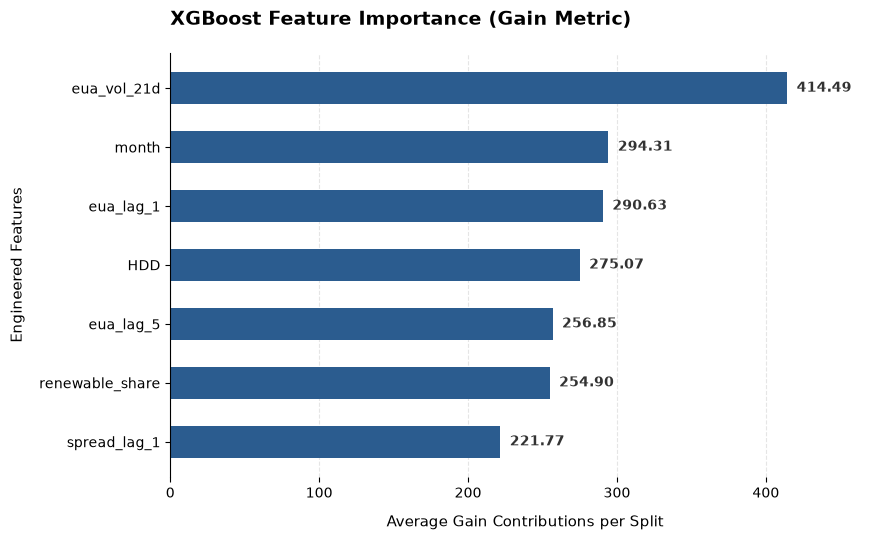

In [9]:
# =========================================================
# STEP 3: CLEAN & PROFESSIONAL PLOTTING
# =========================================================
print("Generating cleaned feature importance chart...")

# 1. Extract the importance scores (gain) directly from the booster object
importance_dict = final_model.get_booster().get_score(importance_type="gain")

# 2. Map scores into a clean Pandas Series and sort them
importance_series = pd.Series(importance_dict).sort_values(ascending=True)

# 3. Initialize a clean, well-spaced plot canvas
fig, ax = plt.subplots(figsize=(9, 5.5))

# 4. Draw modern horizontal bars with a clean corporate palette color
bars = ax.barh(
    importance_series.index, 
    importance_series.values, 
    color="#2b5c8f", 
    edgecolor="none", 
    height=0.55
)

# 5. Add perfectly formatted text labels to the tip of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (importance_series.max() * 0.015),       # Small dynamic spacing off the bar tip
        bar.get_y() + bar.get_height() / 2,             # Vertically centered on the bar
        f"{width:,.2f}",                                # Clean string format: 2 decimal places with commas
        va="center", 
        ha="left", 
        fontsize=10, 
        fontweight="semibold", 
        color="#333333"
    )

# 6. Polish the styling hierarchy
ax.set_title("XGBoost Feature Importance (Gain Metric)", fontsize=14, fontweight="bold", pad=20, loc="left")
ax.set_xlabel("Average Gain Contributions per Split", fontsize=11, fontweight="medium", labelpad=10)
ax.set_ylabel("Engineered Features", fontsize=11, fontweight="medium", labelpad=10)

# Clean up axes & border grids for readability
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True) # Ensure grid lines sit behind the bars

# Remove top, right, and bottom box outline borders ("spines")
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

# Add extra breathing room on the right edge so the labels don't get cut off
ax.set_xlim(0, importance_series.max() * 1.15)
plt.tight_layout()

# Save the polished figure over the old one
plt.savefig("figures/feature_importance.png", dpi=150, bbox_inches="tight")
print("🎉 SUCCESS! Saved polished plot to figures/feature_importance.png")
plt.show()